In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter


##__________________________________________________________________________________________
# Helper Functions
pounds = FuncFormatter(lambda value, _: f"£{value:,.0f}")

def clean_input(value):
    if isinstance(value, str):
        value = value.replace(',', '').replace('£', '').strip()
    return float(value)

# Function to format currency values in DataFrames in formt £xxx,xxx.
def format_currency(val):
    if pd.isna(val) or isinstance(val, str):
        return val
    try:
        return f"£{val:,.0f}"
    except (ValueError, TypeError):
        return val

# Helper function to display DataFrames with formatted currency and no index.
def show_df(df, title=None):
    if title:
        print(title)
    display(
        df.style
          .format(format_currency)
          .hide(axis="index")
    )

##___________________________________________________________________________________________

class Year:

    def __init__(self, year, start_CDEL, start_RDEL, start_RAD):
        
        self.year = year
        self._starting_POT = {
            'Month': 'April',
            'CDEL' : clean_input(start_CDEL),
            'RDEL' : clean_input(start_RDEL),
            'RAD'  : clean_input(start_RAD),
            'TDEL' : clean_input(start_CDEL) + clean_input(start_RDEL) + clean_input(start_RAD)
        }

        self._previous_POT = {
            'Month': None,
            'CDEL' : None,
            'RDEL' : None,
            'RAD'  : None,
            'TDEL' : None
        }

        self._current_POT = dict(self._starting_POT)

        self.monthly_balanced_tracking = {}
        self._balanced_tracking_variance = {}
        self.monthly_pessimistic_tracking = {}
        self.monthly_optimistic_tracking = {}

    def calculate_tracking_variance(self):
        if self._current_POT['Month'] in self.monthly_balanced_tracking and self._current_POT['Month'] != 'April':
            variance = {
                'CDEL' : self._current_POT['CDEL'] - self._previous_POT['CDEL'],
                'RDEL' : self._current_POT['RDEL'] - self._previous_POT['RDEL'],
                'RAD'  : self._current_POT['RAD'] - self._previous_POT['RAD'],
                'TDEL' : self._current_POT['TDEL'] - self._previous_POT['TDEL']
            }
            self._balanced_tracking_variance[self._current_POT['Month']] = variance
            

            return self._balanced_tracking_variance

        else:
            return "Insufficient data available"
    
    #  Returns a single tidy DataFrame with all scenarios — ready for matplotlib.
    def to_dataframe(self):
        rows = []
        for scenario, tracking in [
            ('Balanced',    self.monthly_balanced_tracking),
            ('Pessimistic', self.monthly_pessimistic_tracking),
            ('Optimistic',  self.monthly_optimistic_tracking),
        ]:
            for month, values in tracking.items():
                rows.append({'Month': month, 'Scenario': scenario, **values})
        return pd.DataFrame(rows)

    @property
    def starting_POT(self):
        return self._starting_POT

    @property
    def balanced_tracking(self):
        return self.monthly_balanced_tracking
    
    @property
    def balanced_tracking_variance(self):
        return self._balanced_tracking_variance

    @property
    def previous_POT(self):
        return self._previous_POT

    @property
    def current_POT(self):
        return self._current_POT

    @property
    def current_CDEL_POT(self):
        return self._current_POT['CDEL']

    @property
    def current_RDEL_POT(self):
        return self._current_POT['RDEL']

    @property
    def current_RAD_POT(self):
        return self._current_POT['RAD']

    @property
    def current_TDEL_POT(self):
        return self._current_POT['TDEL']

    @property
    def pessimistic_tracking(self):
        return self.monthly_pessimistic_tracking

    @property
    def optimistic_tracking(self):
        return self.monthly_optimistic_tracking

class Month():

    def __init__(self, year_instance, month, CDEL, RDEL, RAD):
        self.year_instance = year_instance
        self.month = month
        self.CDEL  = clean_input(CDEL)
        self.RDEL  = clean_input(RDEL)
        self.RAD   = clean_input(RAD)
        self.TDEL  = self.CDEL + self.RDEL + self.RAD


        self.year_instance._previous_POT = year_instance._current_POT

        self.year_instance.monthly_balanced_tracking[self.month] = {
            'CDEL': self.CDEL,
            'RDEL': self.RDEL,
            'RAD' : self.RAD,
            'TDEL': self.TDEL
        }

        self.year_instance._current_POT = {
            'Month': self.month,
            'CDEL' : self.CDEL,
            'RDEL' : self.RDEL,
            'RAD'  : self.RAD,
            'TDEL' : self.TDEL
        }

        self.year_instance.calculate_tracking_variance()

    def set_pessimistic_tracking(self, CDEL, RDEL, RAD):
        self.year_instance.monthly_pessimistic_tracking[self.month] = {
            'CDEL': clean_input(CDEL),
            'RDEL': clean_input(RDEL),
            'RAD' : clean_input(RAD),
            'TDEL': clean_input(CDEL) + clean_input(RDEL) + clean_input(RAD)
        }

    def set_optimistic_tracking(self, CDEL, RDEL, RAD):
        self.year_instance.monthly_optimistic_tracking[self.month] = {
            'CDEL': clean_input(CDEL),
            'RDEL': clean_input(RDEL),
            'RAD' : clean_input(RAD),
            'TDEL': clean_input(CDEL) + clean_input(RDEL) + clean_input(RAD)
        }

In [2]:
# This is the ONLY cell the user should edit.

FY26_27 = Year('FY26_27', '£4,700,000', '£220,000', '£80,000')

April = Month(FY26_27, 'April', '£4,620,000', '£250,000', '£130,000')
May = Month(FY26_27, 'May', '£4,680,000', '£235,000', '£115,000')
June = Month(FY26_27, 'June', '£4,790,000', '£260,000', '£140,000')
July = Month(FY26_27, 'July', '£4,730,000', '£310,000', '£105,000')
August = Month(FY26_27, 'August', '£4,850,000', '£245,000', '£155,000')

September = Month(FY26_27, 'September', '£4,920,000', '£290,000', '£170,000')
September.set_pessimistic_tracking('£4,750,000', '£310,000', '£185,000')
September.set_optimistic_tracking('£5,100,000', '£270,000', '£155,000')

October = Month(FY26_27, 'October', '£4,980,000', '£330,000', '£120,000')
October.set_pessimistic_tracking('£4,800,000', '£350,000', '£110,000')
October.set_optimistic_tracking('£5,150,000', '£310,000', '£130,000')

November = Month(FY26_27, 'November', '£4,890,000', '£280,000', '£190,000')
November.set_pessimistic_tracking('£4,750,000', '£300,000', '£175,000')
November.set_optimistic_tracking('£5,050,000', '£260,000', '£210,000')

December = Month(FY26_27, 'December', '£5,040,000', '£300,000', '£160,000')
December.set_pessimistic_tracking('£4,900,000', '£320,000', '£145,000')
December.set_optimistic_tracking('£5,200,000', '£280,000', '£180,000')

January = Month(FY26_27, 'January', '£4,960,000', '£355,000', '£95,000')
January.set_pessimistic_tracking('£4,800,000', '£375,000', '£85,000')
January.set_optimistic_tracking('£5,120,000', '£330,000', '£110,000')

In [3]:
# Dataframes for snapshots of starting, current, previous POT and balanced tracking variance.
df_starting_POT               = pd.DataFrame([FY26_27.starting_POT])
df_current_POT                = pd.DataFrame([FY26_27.current_POT])
df_previous_POT               = pd.DataFrame([FY26_27.previous_POT])
df_balanced_tracking_variance = pd.DataFrame.from_dict(
    FY26_27.calculate_tracking_variance(), orient='index'
).reset_index(names='Month')

# Tidy DataFrame
df_all_scenarios = FY26_27.to_dataframe()

# Sort order controls - helps for dataframe display.
month_order = [
    'April', 'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December',
    'January', 'February', 'March'
 ]
scenario_order = ['Pessimistic', 'Balanced', 'Optimistic']

df_all_scenarios['Month'] = pd.Categorical(
    df_all_scenarios['Month'], categories=month_order, ordered=True
)
df_all_scenarios['Scenario'] = pd.Categorical(
    df_all_scenarios['Scenario'], categories=scenario_order, ordered=True
)
df_all_scenarios = df_all_scenarios.sort_values(['Month', 'Scenario']).reset_index(drop=True)

df_balanced_tracking_variance['Month'] = pd.Categorical(
    df_balanced_tracking_variance['Month'], categories=month_order, ordered=True
)
df_balanced_tracking_variance = df_balanced_tracking_variance.sort_values('Month').reset_index(drop=True)

# We wont need this as we can use all scenarios df and filter in the code.
df_balanced_only = df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']

In [4]:
# Graph 1 - Balanced Tracking vs Starting POT

def plot_tracking_vs_starting_pot(year_instance):
    categories = ['CDEL', 'RDEL', 'RAD']
    starting_values = [year_instance.starting_POT[item] for item in categories]
    current_values = [year_instance.current_POT[item] for item in categories]

    y = np.arange(len(categories))
    bar_height = 0.35

    plt.figure(figsize=(10, 6))
    plt.barh(y - bar_height/2, starting_values, height=bar_height, color='blue', label='Starting POT')
    plt.barh(y + bar_height/2, current_values, height=bar_height, color='orange', label= f'{year_instance.current_POT["Month"]} POT')

    plt.yticks(y, categories)
    plt.gca().invert_yaxis()
    ax = plt.gca()
    ax.xaxis.set_major_formatter(pounds)
    plt.xlabel('Amount (£)')
    plt.title(f'Starting POT vs {year_instance.current_POT["Month"]} POT')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    show_df(df_current_POT, "Current POT")
    show_df(df_starting_POT, "Starting POT")


def plot_balanced_and_3PE(year_instance):
    categories = ['TDEL']

    plt.figure(figsize=(10, 6))
    
    plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['TDEL'], 
             marker='o', label='Balanced', color='green')

    # Only plot pessimistic and optimistic if they have TDEL values (i.e. if they have been set by the user).   
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['TDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['Month'], 
                    df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['TDEL'], 
                    marker='o', label='Pessimistic', color='red')
    
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['TDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['TDEL'], 
             marker='o', label='Optimistic', color='blue')
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(pounds)
    plt.ylabel('TDEL POT (£)')
    plt.ylim(4000000, max(df_all_scenarios['TDEL'].dropna()) * 1.2)  # Set y-axis limit to 20% above max TDEL value

    plt.xlabel('Month')
    plt.xticks(rotation=45)

    plt.title('TDEL POT Forecasting Throughout Year')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    show_df(df_all_scenarios.tail(3), "All Scenarios")

#Need Variance df for all COM - Month, CDEL Pess, RDEL Pess, RAD Pess, TDEL Pess, CDEL bal, RDEL bal, RAD bal, TDEL bal, CDEL Opt, RDEL Opt, RAD Opt, TDEL Opt.
# Finally three graphs outlining the balanced, pessimistic and optimistic tracking for each seperate COM across the year.

def balanced_variance_bar_graph(year_instance):
    if year_instance.balanced_tracking_variance:
        plt.figure(figsize=(10, 6))
        plt.bar(df_balanced_tracking_variance['Month'], df_balanced_tracking_variance['CDEL'], color="#0D3B66")
        plt.bar(df_balanced_tracking_variance['Month'], df_balanced_tracking_variance['RDEL'], color="#1D6FA3")
        plt.bar(df_balanced_tracking_variance['Month'], df_balanced_tracking_variance['RAD'], color="#4FA3D1")       
        plt.xlabel('Month')
        plt.gca().yaxis.set_major_formatter(pounds)
        plt.xticks(rotation=45)
        plt.ylabel('Variance (£)')
        plt.title('Balanced Tracking Variance by Month')
        plt.legend(
            ['CDEL Variance', 'RDEL Variance', 'RAD Variance'],
            loc='upper center',
            bbox_to_anchor=(0.2, -0.3),
            ncol=2,
            frameon=False
        )
        
        plt.hlines(0, xmin=-0.5, xmax=len(df_balanced_tracking_variance)-0.5, colors='grey', linestyles='dashed')
        plt.tight_layout()
        plt.show()
        show_df(df_balanced_tracking_variance.tail(3), "Last Three Months Balanced Tracking Variance")


def CDEL_graph(year_instance):
    plt.figure(figsize=(10, 6))
    plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['CDEL'], 
             marker='o', label='Balanced', color='green')

    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['CDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['Month'], 
                    df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['CDEL'], 
                    marker='o', label='Pessimistic', color='red')
    
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['CDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['CDEL'], 
             marker='o', label='Optimistic', color='blue')
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(pounds)
    plt.ylabel('CDEL POT (£)')
    plt.ylim(4000000, max(df_all_scenarios['CDEL'].dropna()) * 1.2)  # Set y-axis limit to 20% above max CDEL value

    plt.xlabel('Month')
    plt.xticks(rotation=45)

    plt.title('CDEL POT Forecasting Throughout Year')
    
    plt.legend(
        ['Balanced', 'Pessimistic', 'Optimistic'],
        loc='upper center',
        bbox_to_anchor=(0.2, -0.3),
        ncol=2,
        frameon=False
    )
    plt.tight_layout()
    plt.show()
    show_df(df_all_scenarios.tail(3)[['Month', 'Scenario', 'CDEL']],
f"CDEL POT 3PE For {FY26_27.current_POT['Month']}")

def RDEL_graph(year_instance):
    plt.figure(figsize=(10, 6))
    plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['RDEL'], 
             marker='o', label='Balanced', color='green')

    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['RDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['Month'], 
                    df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['RDEL'], 
                    marker='o', label='Pessimistic', color='red')
    
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['RDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['RDEL'], 
             marker='o', label='Optimistic', color='blue')
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(pounds)
    plt.ylabel('RDEL POT (£)')
    plt.ylim(0, max(df_all_scenarios['RDEL'].dropna()) * 1.2)  # Set y-axis limit to 20% above max RDEL value

    plt.xlabel('Month')
    plt.xticks(rotation=45)

    plt.title('RDEL POT Forecasting Throughout Year')
    
    plt.legend(
        ['Balanced', 'Pessimistic', 'Optimistic'],
        loc='upper center',
        bbox_to_anchor=(0.2, -0.3),
        ncol=2,
        frameon=False
    )
    plt.tight_layout()
    plt.show()
    show_df(df_all_scenarios.tail(3)[['Month', 'Scenario', 'RDEL']])

def RDEL_graph(year_instance):
    plt.figure(figsize=(10, 6))
    plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['RDEL'], 
             marker='o', label='Balanced', color='green')

    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['RDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['Month'], 
                    df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['RDEL'], 
                    marker='o', label='Pessimistic', color='red')
    
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['RDEL'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['RDEL'], 
             marker='o', label='Optimistic', color='blue')
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(pounds)
    plt.ylabel('RDEL POT (£)')
    plt.ylim(0, max(df_all_scenarios['RDEL'].dropna()) * 1.2)  # Set y-axis limit to 20% above max RDEL value

    plt.xlabel('Month')
    plt.xticks(rotation=45)

    plt.title('RDEL POT Forecasting Throughout Year')
    
    plt.legend(
        ['Balanced', 'Pessimistic', 'Optimistic'],
        loc='upper center',
        bbox_to_anchor=(0.2, -0.3),
        ncol=2,
        frameon=False
    )
    plt.tight_layout()
    plt.show()
    show_df(df_all_scenarios.tail(3)[['Month', 'Scenario', 'RDEL']],
f"RDEL POT 3PE For {FY26_27.current_POT['Month']}")
    
def RAD_graph(year_instance):
    plt.figure(figsize=(10, 6))
    plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Balanced']['RAD'], 
             marker='o', label='Balanced', color='green')

    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['RAD'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['Month'], 
                    df_all_scenarios[df_all_scenarios['Scenario'] == 'Pessimistic']['RAD'], 
                    marker='o', label='Pessimistic', color='red')
    
    if df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['RAD'] is not None:
        plt.plot(df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['Month'], 
             df_all_scenarios[df_all_scenarios['Scenario'] == 'Optimistic']['RAD'], 
             marker='o', label='Optimistic', color='blue')
    
    ax = plt.gca()
    ax.yaxis.set_major_formatter(pounds)
    plt.ylabel('RAD POT (£)')
    plt.ylim(0, max(df_all_scenarios['RAD'].dropna()) * 1.2)  # Set y-axis limit to 20% above max RAD value

    plt.xlabel('Month')
    plt.xticks(rotation=45)

    plt.title('RAD POT Forecasting Throughout Year')
    
    plt.legend(
        ['Balanced', 'Pessimistic', 'Optimistic'],
        loc='upper center',
        bbox_to_anchor=(0.2, -0.3),
        ncol=2,
        frameon=False
    )
    plt.tight_layout()
    plt.show()
    show_df(df_all_scenarios.tail(3)[['Month', 'Scenario', 'RAD']], f'RAD POT 3PE For {FY26_27.current_POT["Month"]}')


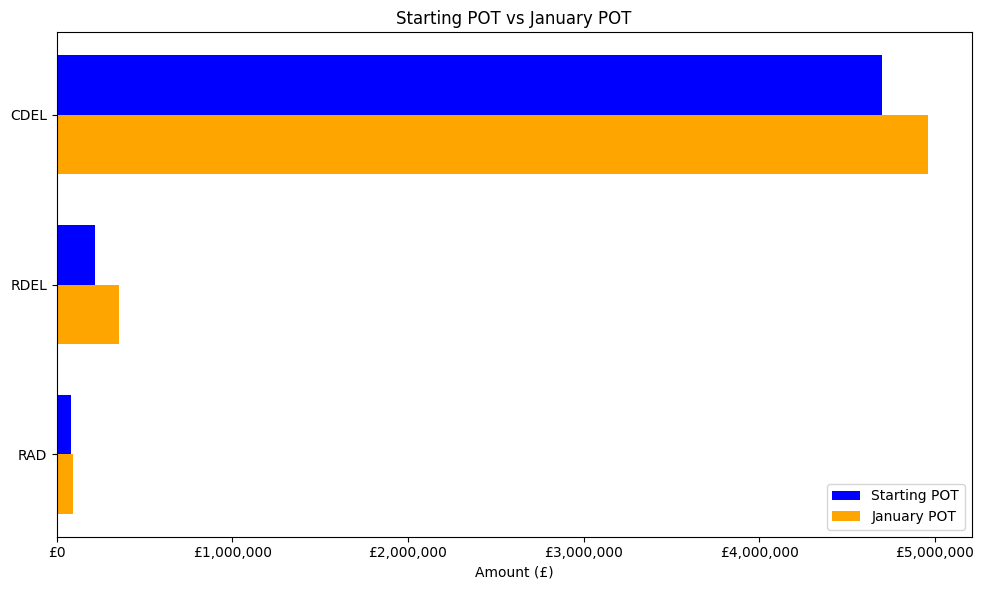

Current POT


Month,CDEL,RDEL,RAD,TDEL
January,"£4,960,000","£355,000","£95,000","£5,410,000"


Starting POT


Month,CDEL,RDEL,RAD,TDEL
April,"£4,700,000","£220,000","£80,000","£5,000,000"


In [5]:
plot_tracking_vs_starting_pot(FY26_27)


#INSERT COMMENTS ON LAST POT VS STARTING POT GRAPH

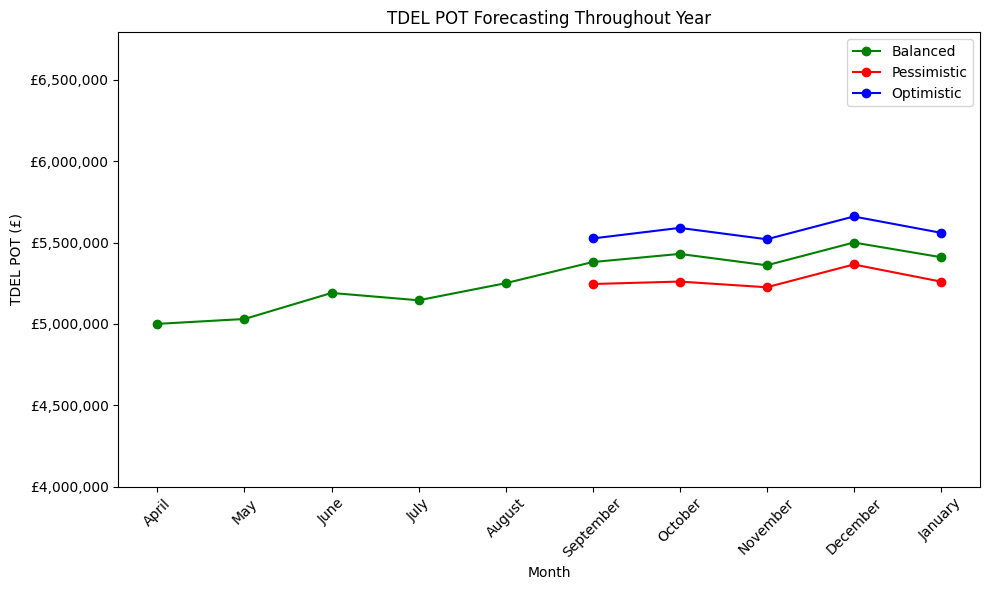

All Scenarios


Month,Scenario,CDEL,RDEL,RAD,TDEL
January,Pessimistic,"£4,800,000","£375,000","£85,000","£5,260,000"
January,Balanced,"£4,960,000","£355,000","£95,000","£5,410,000"
January,Optimistic,"£5,120,000","£330,000","£110,000","£5,560,000"


In [6]:
plot_balanced_and_3PE(FY26_27)


#INSERT COMMENTS ON THE 3PE GRAPH

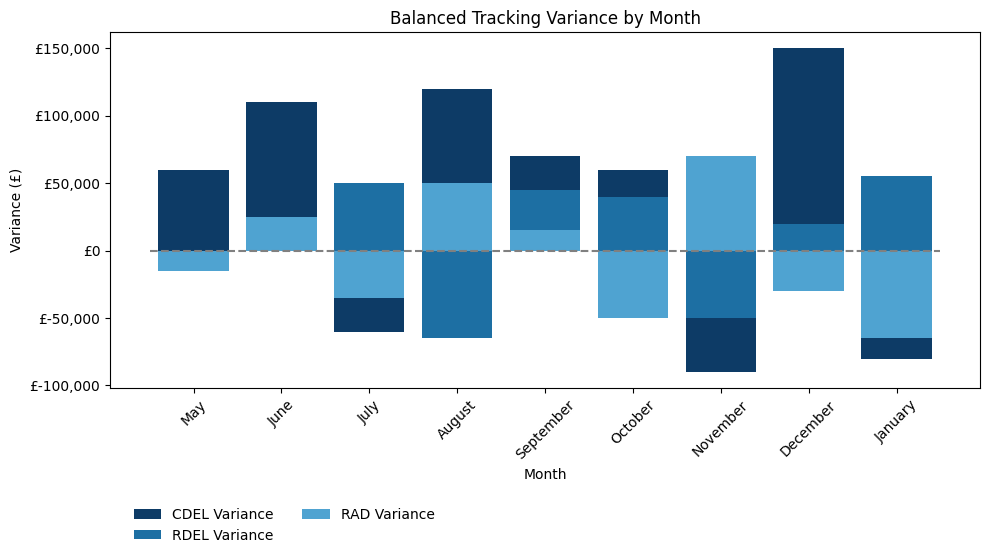

Last Three Months Balanced Tracking Variance


Month,CDEL,RDEL,RAD,TDEL
November,"£-90,000","£-50,000","£70,000","£-70,000"
December,"£150,000","£20,000","£-30,000","£140,000"
January,"£-80,000","£55,000","£-65,000","£-90,000"


In [7]:
balanced_variance_bar_graph(FY26_27)


#INSERT COMMENTS ON BALANCED VARIANCE GRAPH

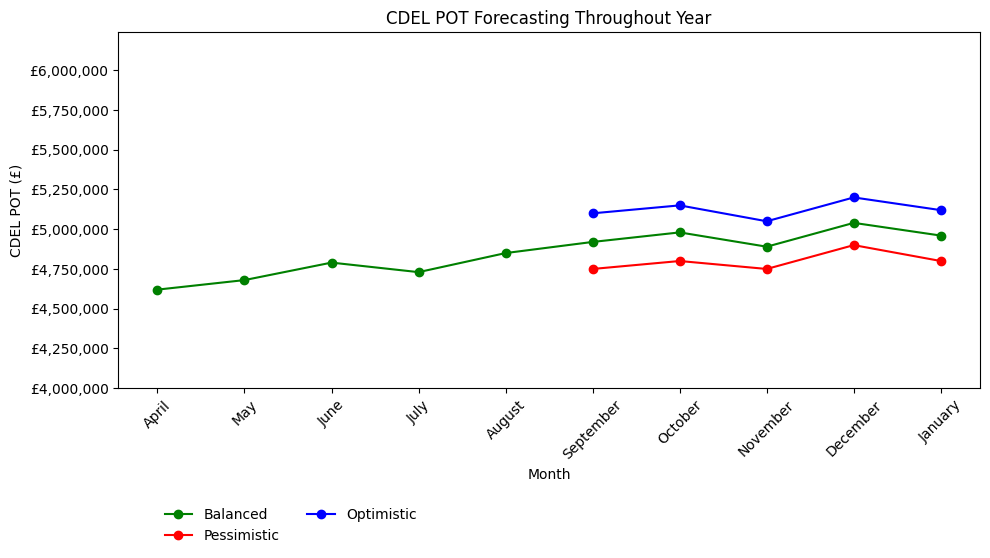

CDEL POT 3PE For January


Month,Scenario,CDEL
January,Pessimistic,"£4,800,000"
January,Balanced,"£4,960,000"
January,Optimistic,"£5,120,000"


In [8]:
CDEL_graph(FY26_27)


#INSERT COMMENTS ON THE CDEL 3PE GRAPH

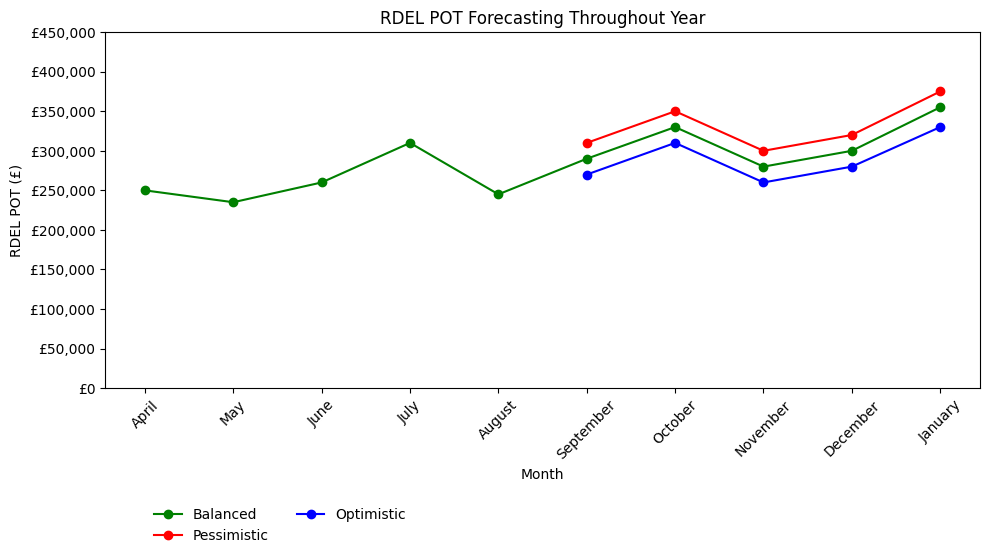

RDEL POT 3PE For January


Month,Scenario,RDEL
January,Pessimistic,"£375,000"
January,Balanced,"£355,000"
January,Optimistic,"£330,000"


In [9]:
RDEL_graph(FY26_27)


#INSERT COMMENTS ON THE RDEL 3PE GRAPH

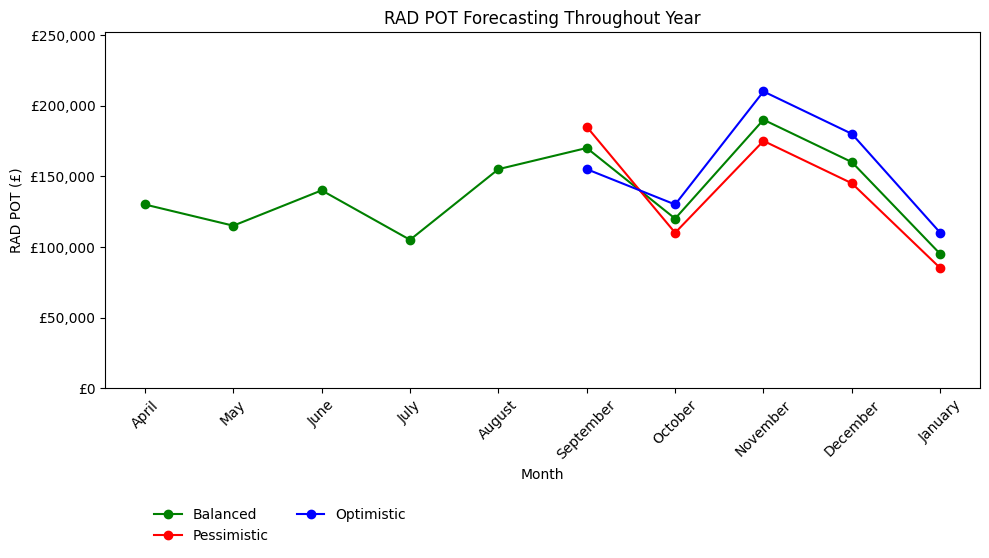

RAD POT 3PE For January


Month,Scenario,RAD
January,Pessimistic,"£85,000"
January,Balanced,"£95,000"
January,Optimistic,"£110,000"


In [10]:
RAD_graph(FY26_27)

#INSERT COMMENTS ON THE RAD 3PE GRAPH